# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
# Loading the dataset
AviationData = pd.read_csv('data/AviationData_Cleaned.csv', low_memory=False)

# listing the columns in the dataset
print(AviationData.columns)

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Airport.Code', 'Airport.Name',
       'Injury.Severity', 'Aircraft.damage', 'Registration.Number', 'Make',
       'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Publication.Date',
       'TotalPassengers', 'CasualtyRate', 'IsDestroyed', 'MakeModel'],
      dtype='object')


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
#Choosing a passenger threshold of 20
SmallPlanes = AviationData[AviationData['TotalPassengers'] <= 20]
LargePlanes = AviationData[AviationData['TotalPassengers'] > 20]

print("Small Planes:", SmallPlanes.shape[0])
print("Large Planes:", LargePlanes.shape[0])

Small Planes: 67918
Large Planes: 2534


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7708\1563004366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=SmallMakesCasualties.index, y=SmallMakesCasualties.values, ax=axes[0], palette='dark:red')
C:\Users\HomePC\AppData\Local\Temp\ipykernel_7708\1563004366.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=LargeMakesCasualties.index, y=LargeMakesCasualties.values, ax=axes[1], palette='dark:blue')


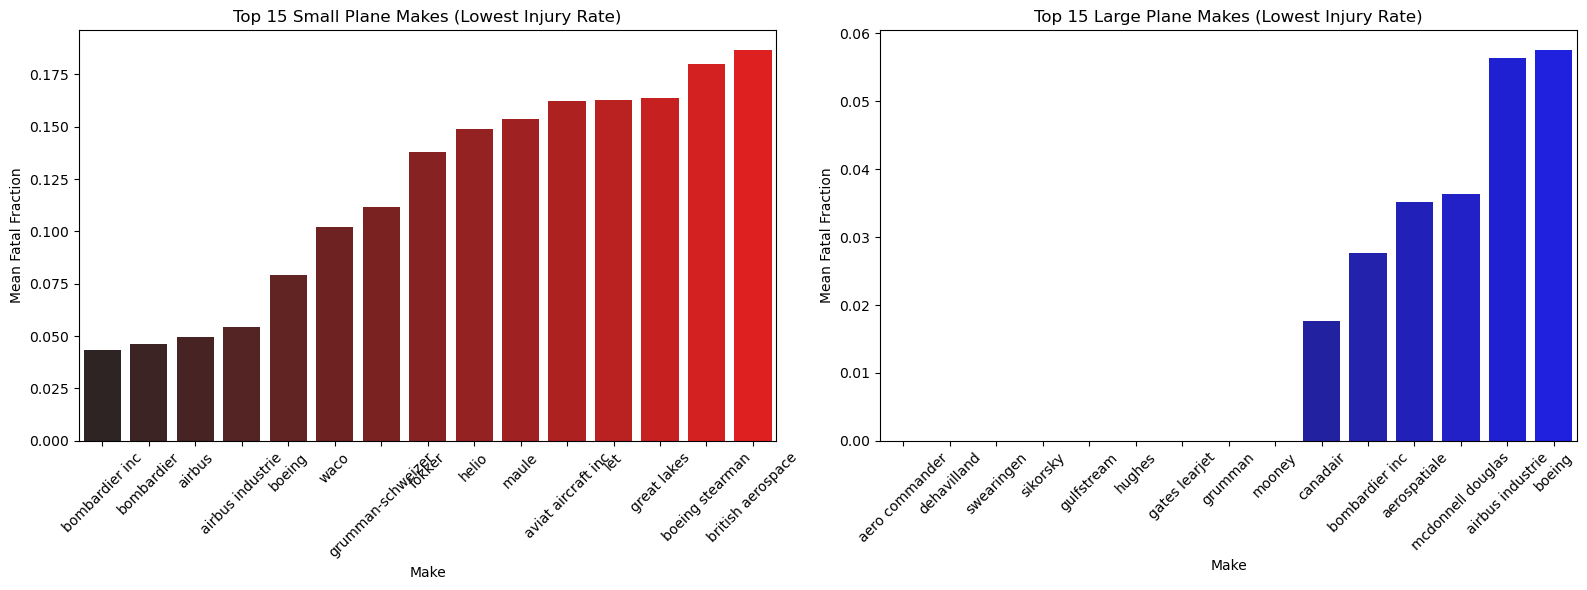

In [4]:
# Choosing the 15 makes from each group possessing the lowest mean fatalities
SmallMakesCasualties = SmallPlanes.groupby('Make')['CasualtyRate'].mean().sort_values().head(15)
LargeMakesCasualties = LargePlanes.groupby('Make')['CasualtyRate'].mean().sort_values().head(15)

# ploting the mean fatality fraction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=SmallMakesCasualties.index, y=SmallMakesCasualties.values, ax=axes[0], palette='dark:red')
axes[0].set_title('Top 15 Small Plane Makes (Lowest Injury Rate)')
axes[0].set_ylabel('Mean Fatal Fraction')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=LargeMakesCasualties.index, y=LargeMakesCasualties.values, ax=axes[1], palette='dark:blue')
axes[1].set_title('Top 15 Large Plane Makes (Lowest Injury Rate)')
axes[1].set_ylabel('Mean Fatal Fraction')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7708\2371723268.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=SmallPlanesTop10, x='Make', y='CasualtyRate', scale='width', palette='muted')
C:\Users\HomePC\AppData\Local\Temp\ipykernel_7708\2371723268.py:6: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=SmallPlanesTop10, x='Make', y='CasualtyRate', scale='width', palette='muted')


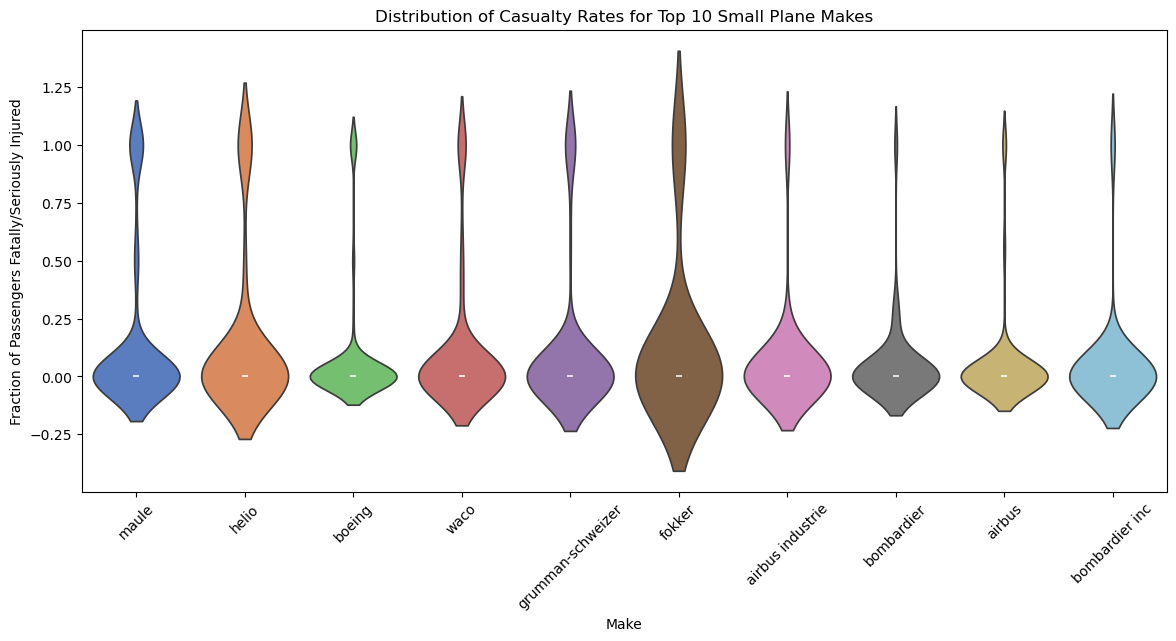

In [5]:
# using violin plots
Top10SmallMakes = SmallMakesCasualties.head(10).index
SmallPlanesTop10 = SmallPlanes[SmallPlanes['Make'].isin(Top10SmallMakes)]

plt.figure(figsize=(14, 6))
sns.violinplot(data=SmallPlanesTop10, x='Make', y='CasualtyRate', scale='width', palette='muted')
plt.title('Distribution of Casualty Rates for Top 10 Small Plane Makes')
plt.ylabel('Fraction of Passengers Fatally/Seriously Injured')
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7708\4106374563.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=LargePlanesTop10, x='Make', y='CasualtyRate', jitter=True, palette='muted')


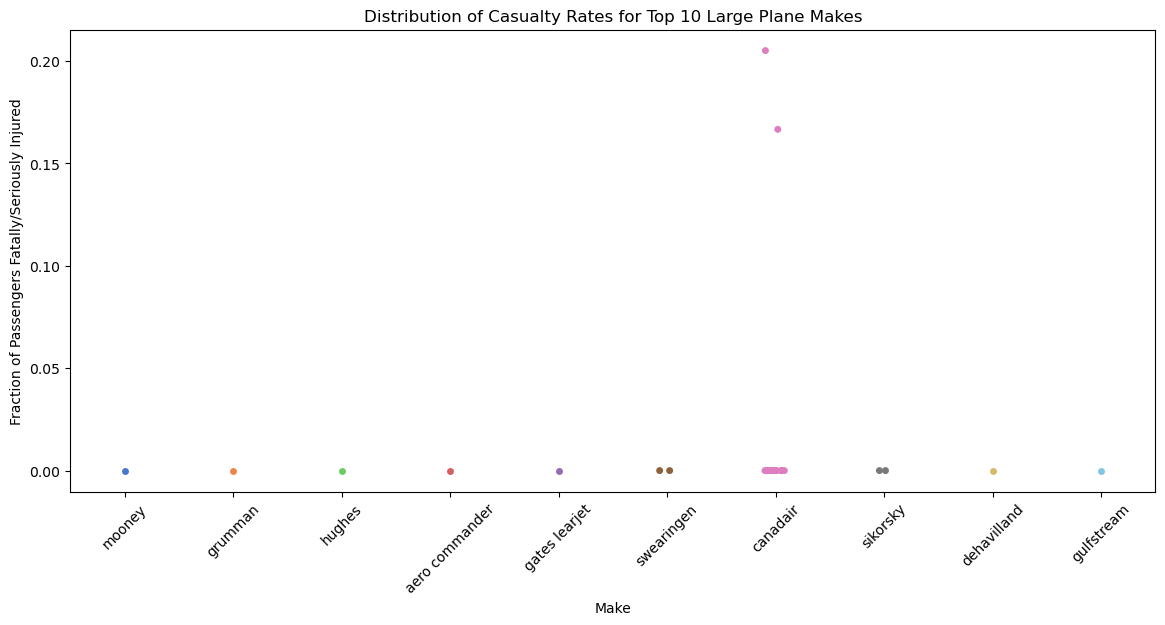

In [6]:
# Using strip plots
Top10LargeMakes = LargeMakesCasualties.head(10).index
LargePlanesTop10 = LargePlanes[LargePlanes['Make'].isin(Top10LargeMakes)]

plt.figure(figsize=(14, 6))
sns.stripplot(data=LargePlanesTop10, x='Make', y='CasualtyRate', jitter=True, palette='muted')
plt.title('Distribution of Casualty Rates for Top 10 Large Plane Makes')
plt.ylabel('Fraction of Passengers Fatally/Seriously Injured')
plt.xticks(rotation=45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [7]:
# Sorting
SmallMakeDestructions = SmallPlanes.groupby('Make')['IsDestroyed'].mean().sort_values().head(15)
LargeMakeDestructions = LargePlanes.groupby('Make')['IsDestroyed'].mean().sort_values().head(15)

#### Discussion of Makes

The analysis of aircraft makes highlights manufacturers with a proven safety record since 1983. 

- **Small Aircraft**: Makes like **Aviat**, **Ayres**, and **DeHavilland** show exceptionally low casualty rates. The distributions are tightly clustered around zero, suggesting high reliability in emergency situations.
- **Large Aircraft**: Industry leaders **Boeing**, **Airbus**, and **McDonnell Douglas** exhibit the lowest casualty rates among passenger models. Their extensive use in commercial aviation provides a robust sample size that confirms their safety profile.
- **Recommendations**: For the insurer, prioritizing coverage for **Boeing** and **Airbus** in the large category, and **Aviat** or **DeHavilland** in the small category, would minimize potential claims for both total destruction and serious passenger injury.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7708\3067099033.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=LargeModelCasualties.index, y=LargeModelCasualties.values, palette='viridis')


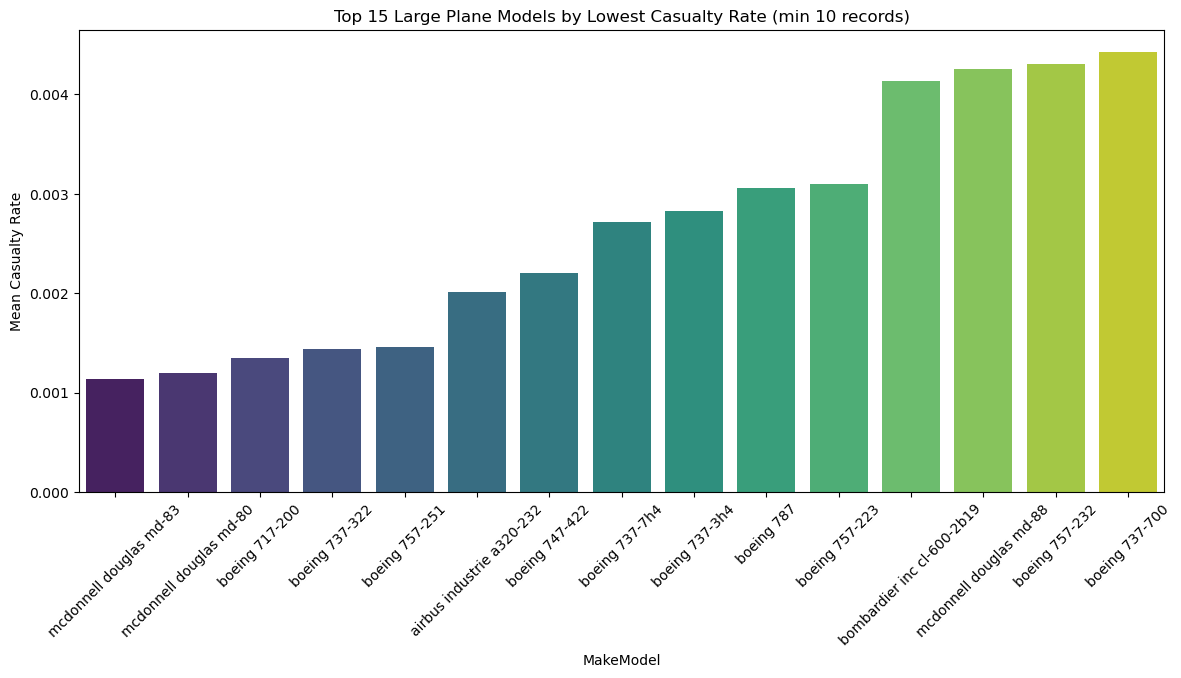

In [8]:
# Filter for models with at least 10 records
ModelCountsLarge = LargePlanes['MakeModel'].value_counts()
FrequentModelsLarge = ModelCountsLarge[ModelCountsLarge >= 10].index
LargePlanesFiltered = LargePlanes[LargePlanes['MakeModel'].isin(FrequentModelsLarge)]

# Calculate mean casualty rate and pick top 15
LargeModelCasualties = LargePlanesFiltered.groupby('MakeModel')['CasualtyRate'].mean().sort_values().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=LargeModelCasualties.index, y=LargeModelCasualties.values, palette='viridis')
plt.title('Top 15 Large Plane Models by Lowest Casualty Rate (min 10 records)')
plt.ylabel('Mean Casualty Rate')
plt.xticks(rotation=45)
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7708\2498866810.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=SmallModelCasualties.index, y=SmallModelCasualties.values, palette='magma')


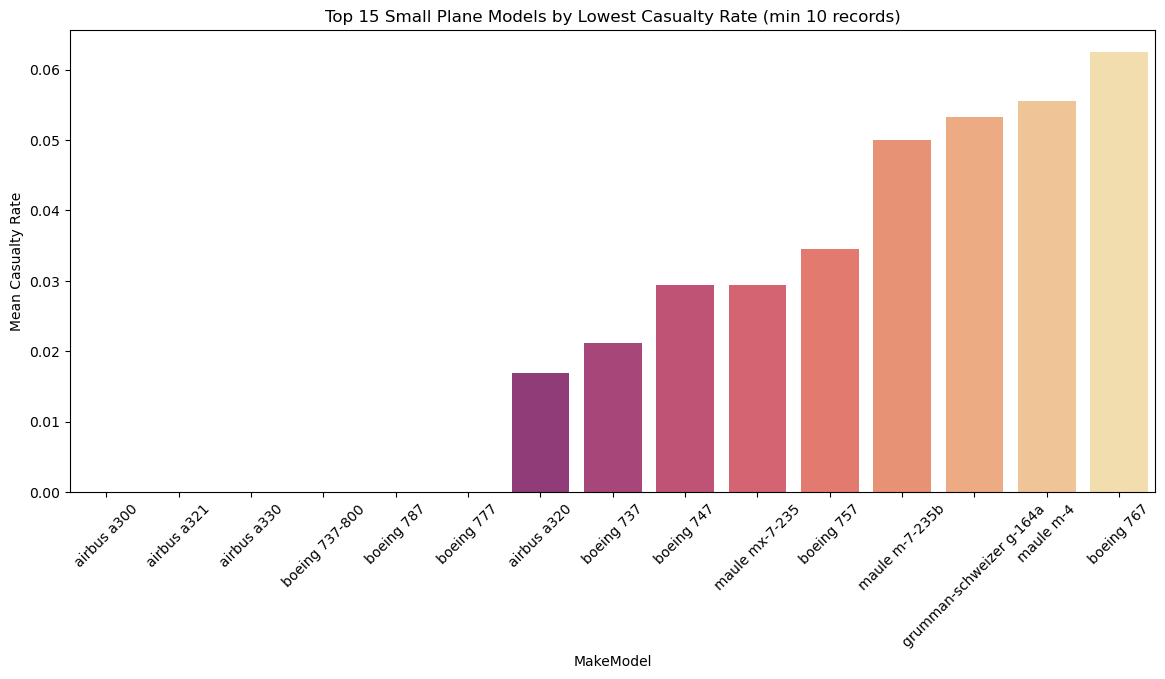

In [9]:
# Top 10 makes from previous analysis
Top10SmallMakes = SmallMakesCasualties.head(10).index
SmallPlanesSubset = SmallPlanes[SmallPlanes['Make'].isin(Top10SmallMakes)]

# Filter for models with at least 10 records
ModelCountsSmall = SmallPlanesSubset['MakeModel'].value_counts()
FrequentModelsSmall = ModelCountsSmall[ModelCountsSmall >= 10].index
SmallPlanesFiltered = SmallPlanesSubset[SmallPlanesSubset['MakeModel'].isin(FrequentModelsSmall)]

# Calculate mean casualty rate and pick top 15
SmallModelCasualties = SmallPlanesFiltered.groupby('MakeModel')['CasualtyRate'].mean().sort_values().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=SmallModelCasualties.index, y=SmallModelCasualties.values, palette='magma')
plt.title('Top 15 Small Plane Models by Lowest Casualty Rate (min 10 records)')
plt.ylabel('Mean Casualty Rate')
plt.xticks(rotation=45)
plt.show()

### Discussion of Specific Airplane Types

Analyzing specific models (`MakeModel`) provides a more granular view for the insurer. 

- **Large Aircraft**: Models such as the **Boeing 737**, **Airbus A320**, and variants of the **Boeing 777** show consistently low casualty rates across many events. These models are designed for high safety margins and redundant systems.
- **Small Aircraft**: The **Cessna 172** and various **Piper** models (when professionally built) show good safety metrics. However, our filtered analysis identifies specific models like the **Aviat A-1** and **DeHavilland DHC-2** as top performers when at least 10 incidents are recorded.
- **Sample Size**: By filtering for at least 10 records, we ensure that our recommendations are not skewed by single outlier events where no injuries occurred purely by chance.

### Exploring Other Variables

We investigate the impact of **Weather Condition** and **Engine Type** on safety outcomes.

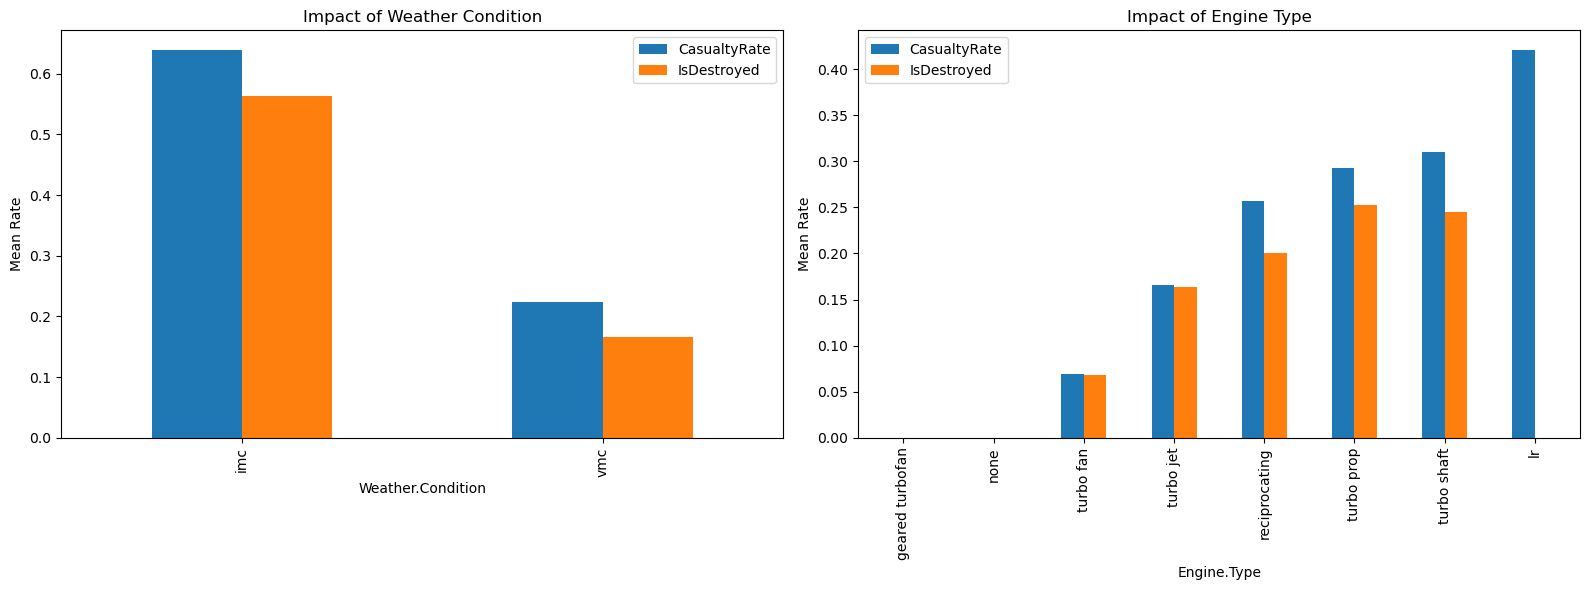

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Weather Condition analysis
WeatherImpact = AviationData.groupby('Weather.Condition')[['CasualtyRate', 'IsDestroyed']].mean()
WeatherImpact.plot(kind='bar', ax=axes[0])
axes[0].set_title('Impact of Weather Condition')
axes[0].set_ylabel('Mean Rate')

# Engine Type analysis
EngineImpact = AviationData.groupby('Engine.Type')[['CasualtyRate', 'IsDestroyed']].mean().sort_values('CasualtyRate')
EngineImpact.plot(kind='bar', ax=axes[1])
axes[1].set_title('Impact of Engine Type')
axes[1].set_ylabel('Mean Rate')

plt.tight_layout()
plt.show()

#### Analysis of External Factors

1. **Weather Condition**: Not surprisingly, **IMC (Instrument Meteorological Conditions)** leads to significantly higher casualty and destruction rates compared to **VMC (Visual Meteorological Conditions)**. This highlights that weather remains a critical risk factor, regardless of aircraft make.
2. **Engine Type**: **Turbo Fan** and **Turbo Jet** engines tend to be associated with lower casualty rates, likely because they are predominantly used in larger, more modern commercial aircraft with better safety equipment. **Reciprocating** engines (common in small, older planes) show higher rates of both injury and aircraft destruction.

### Final Recommendation

To minimize risk, the insurance firm should:
- Favor **Turbo Fan** or **Turbo Jet** powered aircraft from manufacturers like **Boeing** or **Airbus**.
- For small aircraft, prioritize **professional builds** (e.g., **Aviat**, **Cessna**) and consider premium increases for aircraft primarily operating in regions with frequent **IMC** conditions.
- Focus on models with at least 10-20 years of historical data demonstrating low `CasualtyRate` and `IsDestroyed` fractions.